In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Load ERA5/Obs data

In [ ]:
def df_xr_prep(df):
    da=df.to_xarray()
    da=da.rename({'index':'year'})
    return da

##La Plata
#SON
era_SON_LaPlata_df=pd.read_csv('../data_ready/7_with_VB.csv',index_col='Unnamed: 0')

#era_SON_LaPlata_df=era_SON_LaPlata_df.rename(index_col='year')
era_SON_LaPlata_array=era_SON_LaPlata_df.to_xarray()
era_SON_LaPlata_array=era_SON_LaPlata_array.rename({'index':'year'})

#DJF
era_DJF_LaPlata_df=pd.read_csv('../data_ready/6_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_LaPlata_array=df_xr_prep(era_DJF_LaPlata_df)

##Andes
#SON
era_SON_Andes_df=pd.read_csv('../data_ready/5_with_VB.csv',index_col='Unnamed: 0')
era_SON_Andes_array=df_xr_prep(era_SON_Andes_df)

#DJF
era_DJF_Andes_df=pd.read_csv('../data_ready/4_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_Andes_array=df_xr_prep(era_DJF_Andes_df)
display(era_DJF_Andes_array)

<xarray.Dataset> Size: 8kB
Dimensions:        (year: 73)
Coordinates:
  * year           (year) int64 584B 1951 1952 1953 1954 ... 2022 2023 2024 1950
Data variables: (12/13)
    t_Andes        (year) float64 584B -1.791 0.5614 -0.2617 ... 0.6017 nan
    precip_Andes   (year) float64 584B 0.129 0.4549 -1.375 ... -0.2223 -1.51 nan
    ENSO           (year) float64 584B -0.6866 0.5838 0.3068 ... 1.632 nan
    IOD            (year) float64 584B 0.2555 0.6281 1.26 ... 0.9651 4.209 nan
    EDJ            (year) float64 584B 1.783 0.6677 -0.5056 ... 0.1875 nan
    EDJ_lat        (year) float64 584B -0.6985 1.359 -0.9556 ... -2.241 nan
    ...             ...
    SPV            (year) float64 584B 0.2633 -0.6312 1.451 ... 1.702 1.85 nan
    A_SAM          (year) float64 584B 0.233 -1.135 -2.197 ... 1.774 0.05365 nan
    S_SAM          (year) float64 584B 0.6038 -1.058 0.1437 ... 1.93 1.88 nan
    IOBW           (year) float64 584B -1.546 0.8591 -0.3374 ... 2.389 nan
    VB             (year) float64 584B -0.0653 -0.101 0.2247 ... 0.7241 nan
    VB_class       (year) object 584B 'Early' 'Early' 'Late' ... 'Late' 'Early'

Load Hindcast data

In [ ]:
path='/climca/people/glattus/Hindcast_data_ready/'
ds_Andes_SON=xr.open_dataset(path+'Target_vars_Andes_SON.nc')
ds_Andes_DJF=xr.open_dataset(path+'Target_vars_Andes_DJF.nc')
def drop_duplicates(ds):
    ds = ds.sortby(["forecast_reference_time", "number", "lead_block"])
    ds = ds.drop_duplicates(dim="sample")
    return ds

ds_Andes_SON=drop_duplicates(ds_Andes_SON)
ds_Andes_DJF=drop_duplicates(ds_Andes_DJF)

ds_LP_SON=xr.open_dataset(path+'Target_vars_LP_SON.nc')
ds_LP_DJF=xr.open_dataset(path+'Target_vars_LP_DJF.nc')

ds_LP_SON=drop_duplicates(ds_LP_SON)
ds_LP_DJF=drop_duplicates(ds_LP_DJF)

display(ds_LP_SON.sizes)
display(ds_LP_SON)

Frozen({'sample': 6426})

<xarray.Dataset> Size: 951kB
Dimensions:                  (sample: 6426)
Coordinates:
    lead_block               (sample) <U10 257kB ...
    forecast_reference_time  (sample) datetime64[ns] 51kB ...
    number                   (sample) int64 51kB ...
    real_season              (sample) <U3 77kB ...
    real_months              (sample) <U8 206kB ...
    season_label             (sample) <U8 206kB ...
Dimensions without coordinates: sample
Data variables:
    t2m                      (sample) float64 51kB ...
    tprate                   (sample) float64 51kB ...

In [ ]:
#load indices data
ds_ocean_SON=xr.open_dataset(path+'ENSO_IOD_SON.nc')
ds_ocean_DJF=xr.open_dataset(path+'ENSO_IOB_DJF.nc')

ds_ocean_SON=drop_duplicates(ds_ocean_SON)
ds_ocean_DJF=drop_duplicates(ds_ocean_DJF)



In [ ]:
#ds_strato_SON=xr.open_dataset(path+'SPV_SON.nc')
#ds_strato_DJF=xr.open_dataset(path+'SPV_DJF.nc')

Bootstrap hindcast data from the different ensembles

In [ ]:
ds_Andes_SON.sizes

Frozen({'sample': 6426})

In [ ]:
test = ds_Andes_SON['t2m'].where(
    (ds_Andes_SON["forecast_reference_time"] == '1987-09-01T00:00:00.000000000') &
    (ds_Andes_SON["number"] == 1) &
    (ds_Andes_SON["lead_block"] ==  'lead_1_2_3')
)
#1987-09-01T00:00:00.000000000 28 lead_4_5_6
print(test)

<xarray.DataArray 't2m' (sample: 6426)> Size: 51kB
array([nan, nan, nan, ..., nan, nan, nan], shape=(6426,))
Coordinates:
    lead_block               (sample) <U10 257kB 'lead_4_5_6' ... 'lead_1_2_3'
    forecast_reference_time  (sample) datetime64[ns] 51kB 1981-06-01 ... 2022...
    number                   (sample) int64 51kB 0 1 2 3 4 5 ... 48 49 49 50 50
    real_season              (sample) <U3 77kB 'SON' 'SON' 'SON' ... 'SON' 'SON'
    real_months              (sample) <U8 206kB '09-10-11' ... '09-10-11'
    season_label             (sample) <U8 206kB 'SON_1981' ... 'SON_2022'
Dimensions without coordinates: sample


In [ ]:
len_boot=len(era_DJF_Andes_array.year)
print(len_boot)

73


In [ ]:
import numpy as np

def generate_samples(ds, var, len_boot=60):

    ds = ds[var]  # DataArray

    years = np.unique(ds.forecast_reference_time.values)
    members = np.unique(ds.number.values)
    leads = np.unique(ds.lead_block.values)

    samples = np.empty(len_boot)

    for i in range(len_boot):

        year = np.random.choice(years)
        member = np.random.choice(members)
        lead = np.random.choice(leads)

        try:
            value = ds.sel(
                sample=(year, member, lead)
            ).values.item()
        except Exception:
            value = np.nan

        samples[i] = value

    return samples

def bootstrap_chain(ds, iterations, var):

    return np.stack([
        generate_samples(ds, var, len_boot=60)
        for _ in range(iterations)
    ])

import matplotlib.pyplot as plt

def model_eval_plot(boot_samples, era5_array, input_title):

    # boot_samples: (n_boot, sample_size)
    # era5_array: (sample_size,)

    boot_percentiles = np.nanpercentile(
        boot_samples,
        np.arange(0, 100),
        axis=1
    )

    era5_percentiles = np.nanpercentile(
        era5_array,
        np.arange(0, 100)
    )

    boot_mean = np.nanmean(boot_percentiles, axis=1)
    boot_std = np.nanstd(boot_percentiles, axis=1)

    fig = plt.figure(figsize=(6, 6))

    plt.plot(era5_percentiles, era5_percentiles, "k-", label="1:1 line")

    plt.scatter(
        era5_percentiles,
        boot_mean,
        color="blue",
        label="Bootstrap mean"
    )

    plt.fill_between(
        era5_percentiles,
        boot_mean - boot_std,
        boot_mean + boot_std,
        alpha=0.4,
        label="±1σ"
    )

    plt.xlabel("ERA5 (observed) data")
    plt.ylabel("Hindcast model data")
    plt.title(input_title)
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

    return boot_percentiles, era5_percentiles, fig


In [ ]:
ds_Andes_SON = ds_Andes_SON.set_index(
    sample=["forecast_reference_time", "number", "lead_block"]
)

ds_Andes_DJF = ds_Andes_DJF.set_index(
    sample=["forecast_reference_time", "number", "lead_block"]
)
print(list(ds_Andes_SON.data_vars))

['t2m', 'tprate']


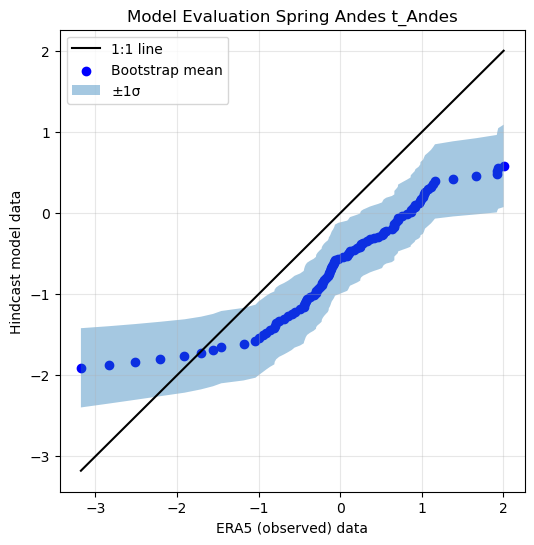

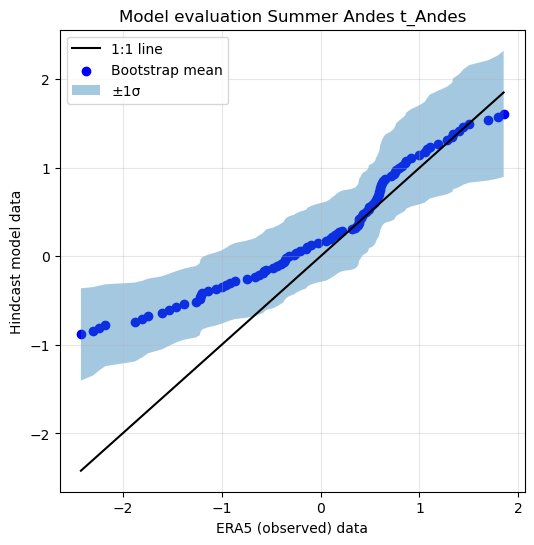

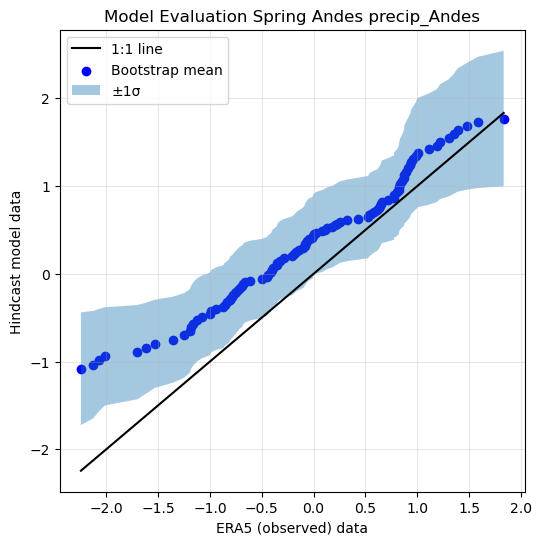

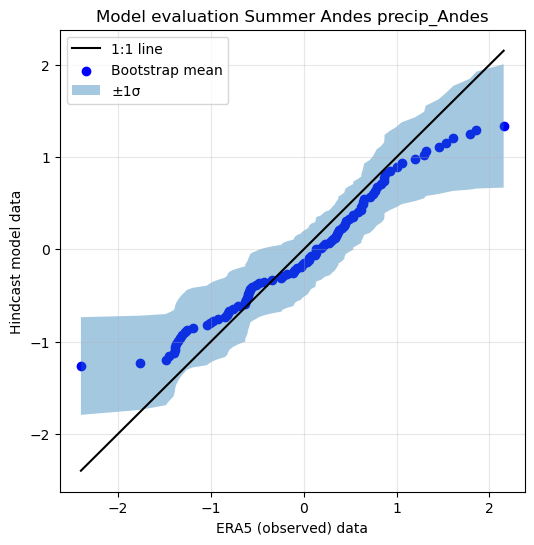

In [ ]:
folder='Model_eval_plots/'
mapping = {
    list(ds_Andes_DJF.data_vars)[0]: "t_Andes",
    list(ds_Andes_DJF.data_vars)[1]: "precip_Andes"  
}
for var, era_var in mapping.items():
    a=bootstrap_chain(ds_Andes_SON, 60, var=var)
    boot_perc_Andes_SON, era5_perc_Andes_SON, fig_Andes=model_eval_plot(a, era5_array=era_SON_Andes_array[era_var],
                                                input_title=f'Model Evaluation Spring Andes {era_var}')
    fig_Andes.savefig(folder+f'model_eval_Andes_spring_{era_var}.jpg', dpi=300)
    b=bootstrap_chain(ds_Andes_DJF, 60, var=var)
    boot_perc_Andes_DJF, era5_perc_Andes_DJF, fig_Andes_DJF=model_eval_plot(b,
                                                             era_DJF_Andes_array[era_var],
                                                             input_title=f'Model evaluation Summer Andes {era_var}')
    fig_Andes_DJF.savefig(folder+f'model_eval_Andes_summer_{era_var}.jpg', dpi=300)

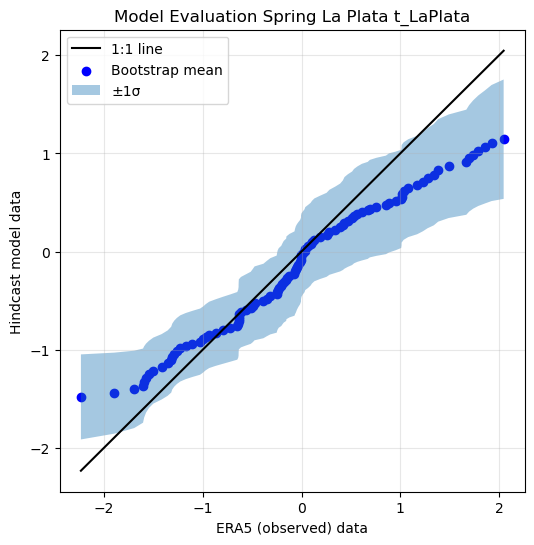

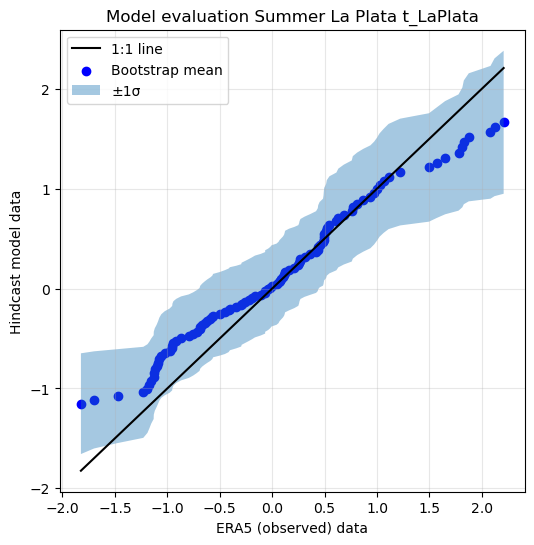

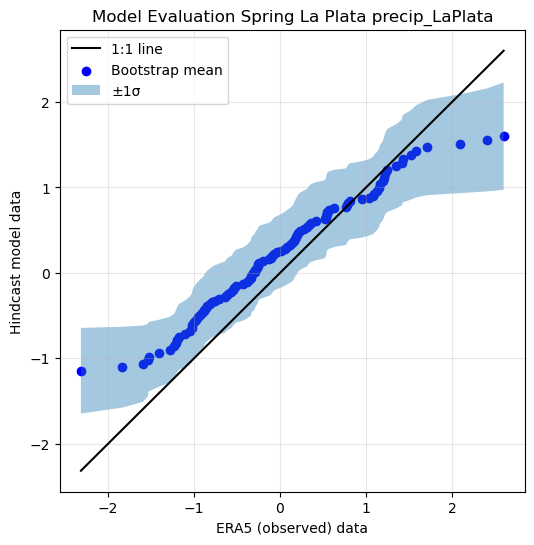

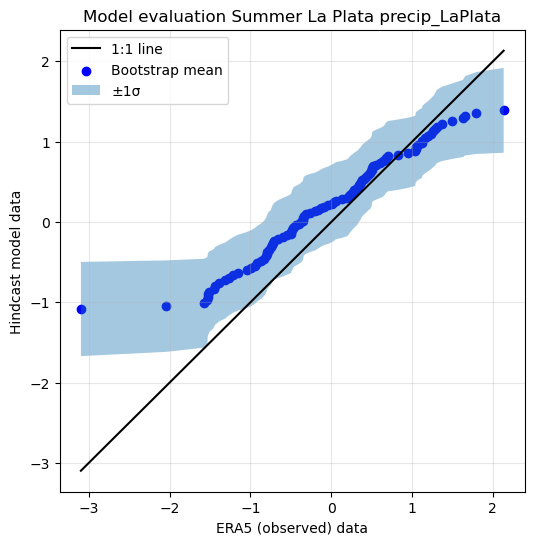

In [ ]:
ds_LP_SON = ds_LP_SON.set_index(
    sample=["forecast_reference_time", "number", "lead_block"]
)

ds_LP_DJF = ds_LP_DJF.set_index(
    sample=["forecast_reference_time", "number", "lead_block"]
)
folder='Model_eval_plots'
mapping2 = {
    list(ds_LP_DJF.data_vars)[0]: "t_LaPlata",
    list(ds_LP_DJF.data_vars)[1]: "precip_LaPlata"  
}
for var, era_var in mapping2.items():
    a=bootstrap_chain(ds_LP_SON, 60, var=var)
    boot_perc_LP_SON, era5_perc_LP_SON, fig_LP=model_eval_plot(a, era5_array=era_SON_LaPlata_array[era_var],
                                                input_title=f'Model Evaluation Spring La Plata {era_var}')
    fig_LP.savefig(folder+f'model_eval_LP_spring_{era_var}.jpg', dpi=300)
    b=bootstrap_chain(ds_LP_DJF, 60, var=var)
    boot_perc_LP_DJF, era5_perc_LP_DJF, fig_LP_DJF=model_eval_plot(b,
                                                             era_DJF_LaPlata_array[era_var],
                                                             input_title=f'Model evaluation Summer La Plata {era_var}')
    fig_LP_DJF.savefig(folder+f'model_eval_LP_summer_{era_var}.jpg', dpi=300)

Evaluate computed indices

In [ ]:
ds_ocean_SON=ds_ocean_SON.set_index()

<xarray.Dataset> Size: 951kB
Dimensions:                  (sample: 6426)
Coordinates:
    lead_block               (sample) <U10 257kB ...
    forecast_reference_time  (sample) datetime64[ns] 51kB ...
    number                   (sample) int64 51kB ...
    real_season              (sample) <U3 77kB ...
    real_months              (sample) <U8 206kB ...
    season_label             (sample) <U8 206kB ...
Dimensions without coordinates: sample
Data variables:
    iod_index                (sample) float64 51kB ...
    nino34                   (sample) float64 51kB ...

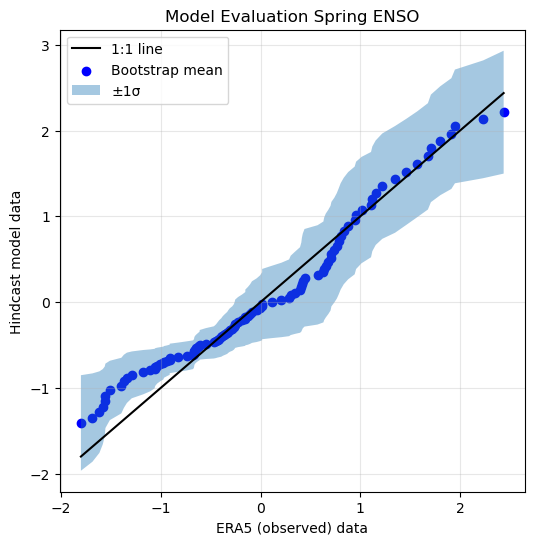

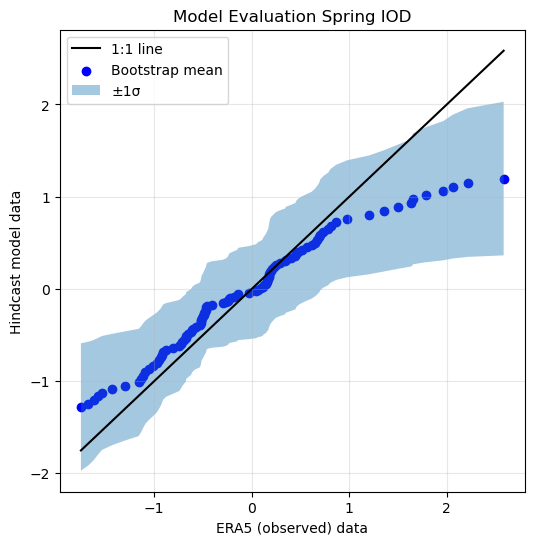

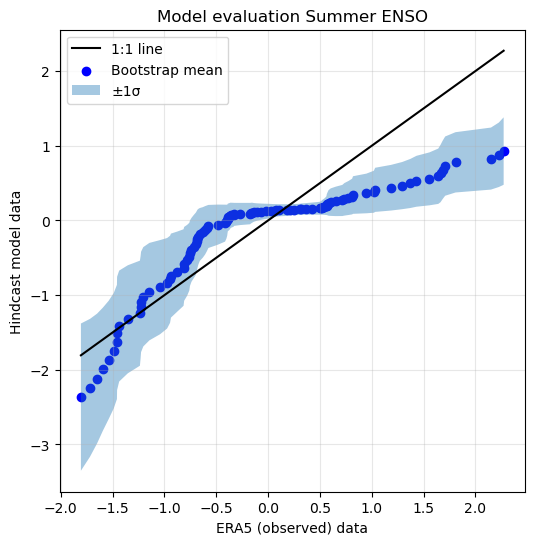

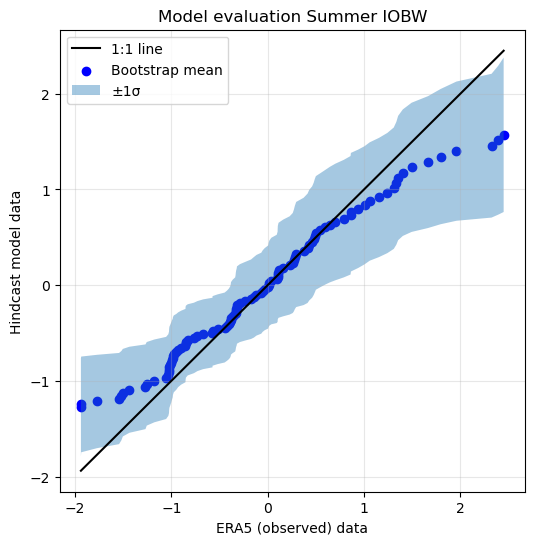

In [ ]:
ds_ocean_SON = ds_ocean_SON.set_index(
    sample=["forecast_reference_time", "number", "lead_block"]
)

ds_ocean_DJF = ds_ocean_DJF.set_index(
    sample=["forecast_reference_time", "number", "lead_block"]
)
folder='Model_eval_plots'
mapping_oc_SON = {
    list(ds_ocean_SON.data_vars)[0]: "ENSO",
    list(ds_ocean_SON.data_vars)[1]: "IOD"  
}
mapping_oc_DJF = {
    list(ds_ocean_DJF.data_vars)[0]: "ENSO",
    list(ds_ocean_DJF.data_vars)[1]: "IOBW"  
}
for var, era_var in mapping_oc_SON.items():
    a=bootstrap_chain(ds_ocean_SON, 60, var=var)
    boot_perc_oc_SON, era5_perc_oc_SON, fig_oc=model_eval_plot(a, era5_array=era_SON_LaPlata_array[era_var],
                                                input_title=f'Model Evaluation Spring {era_var}')
    fig_oc.savefig(folder+f'model_eval_spring_{era_var}.jpg', dpi=300)

for var, era_var in mapping_oc_DJF.items():
    b=bootstrap_chain(ds_ocean_DJF, 60, var=var)
    boot_perc_oc_DJF, era5_perc_oc_DJF, fig_oc_DJF=model_eval_plot(b,
                                                             era_DJF_LaPlata_array[era_var],
                                                             input_title=f'Model evaluation Summer {era_var}')
    fig_oc_DJF.savefig(folder+f'model_eval_summer_{era_var}.jpg', dpi=300)